**Import Tools**

In [1]:
!pip install xgboost catboost lightgbm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("dark_background")
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,MinMaxScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


**Load Data**

In [3]:
train_data = pd.read_csv("/kaggle/input/playground-series-s6e1/train.csv")
train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [4]:
test_data = pd.read_csv("/kaggle/input/playground-series-s6e1/test.csv")
test_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [5]:
sample_submission = pd.read_csv("/kaggle/input/playground-series-s6e1/sample_submission.csv")
sample_submission.head()

,id,exam_score
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [7]:
train_data.isna().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [8]:
train_data.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [9]:
train_data.describe(include="O")

,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
count,630000,630000,630000,630000,630000,630000,630000
unique,3,7,2,3,5,3,3
top,other,b.tech,yes,poor,coaching,medium,moderate
freq,211097,131236,579423,213675,131697,214082,353982


In [10]:
train_data[train_data.duplicated()]

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score


**EDA**

In [11]:
min_age = train_data.age.min()
max_age = train_data.age.max()
print(f"Young Age: {min_age} , Largest Age: {max_age}")

Young Age: 17 , Largest Age: 24


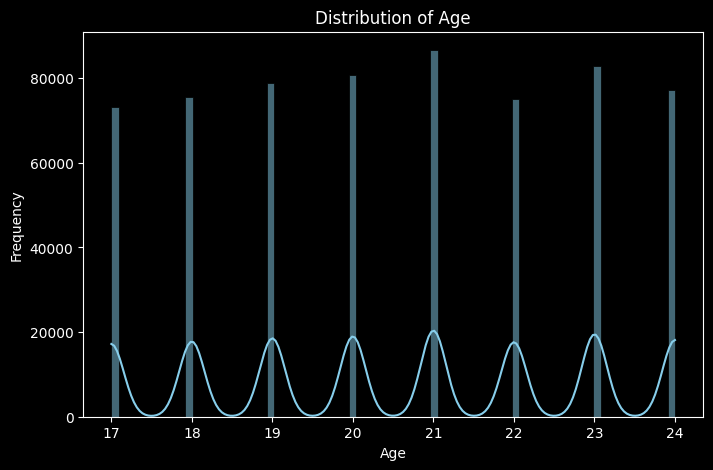

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(train_data['age'], kde=True, color='skyblue', edgecolor='black')  
plt.title("Distribution of Age", fontsize=12)  
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [13]:
train_data.gender.value_counts()

gender
other     211097
male      210593
female    208310
Name: count, dtype: int64

In [14]:
df = train_data.groupby(["gender"])["exam_score"].aggregate(["min","max","mean","median"])
df

,min,max,mean,median
gender,,,,
female,19.599,100.0,62.563220,62.5
male,19.599,100.0,62.175561,62.5
other,19.599,100.0,62.781191,62.6


/tmp/ipykernel_23/747602385.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index,y=df["mean"],palette="Set1_r")


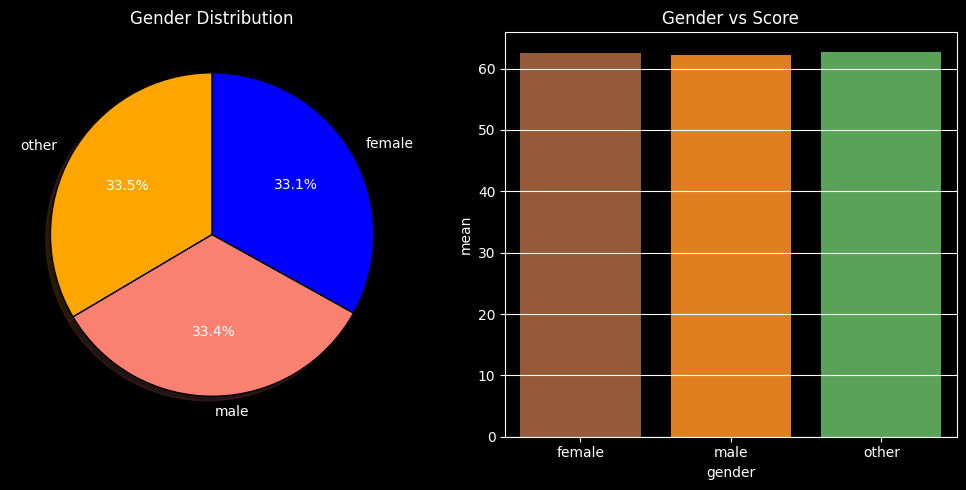

In [15]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.pie(
    x=train_data['gender'].value_counts().values,
    labels=train_data['gender'].value_counts().index,
    autopct='%1.1f%%',  
    colors=['orange','salmon','blue'],  
    startangle=90,
    shadow=True,
    wedgeprops={'edgecolor':'black'}  
)
plt.title("Gender Distribution",fontsize=12)
plt.subplot(1,2,2)
sns.barplot(x=df.index,y=df["mean"],palette="Set1_r")
plt.title("Gender vs Score",fontsize=12)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [16]:
train_data.course.value_counts()

course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64

In [17]:
df = train_data.groupby(["gender","course"])["exam_score"].aggregate(["min","max","mean","median"]).reset_index()
df

,gender,course,min,max,mean,median
0,female,b.com,19.599,100.0,62.414212,62.1
1,female,b.sc,19.599,100.0,62.597450,63.3
2,female,b.tech,19.599,100.0,62.615739,62.5
3,female,ba,19.599,100.0,61.869139,62.2
4,female,bba,19.599,100.0,63.358199,63.4
5,female,bca,19.599,100.0,62.637004,62.5
6,female,diploma,19.599,100.0,62.266413,61.7
7,male,b.com,19.599,100.0,62.335723,62.3
8,male,b.sc,19.599,100.0,61.889537,63.0
9,male,b.tech,19.599,100.0,62.150582,62.3


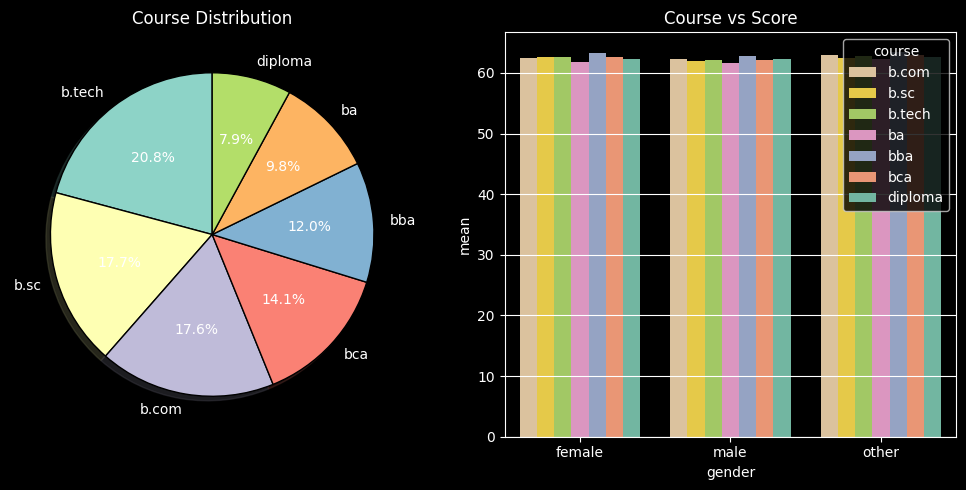

In [18]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.pie(
    x=train_data['course'].value_counts().values,
    labels=train_data['course'].value_counts().index,
    autopct='%1.1f%%',  
    startangle=90,
    shadow=True,    
    wedgeprops={'edgecolor':'black'}  
)
plt.title("Course Distribution",fontsize=12)
plt.subplot(1,2,2)
sns.barplot(x=df["gender"],y=df["mean"],hue=df["course"],palette="Set2_r")
plt.title("Course vs Score",fontsize=12)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [19]:
min_study_hours = train_data.study_hours.min()
max_study_hours = train_data.study_hours.max()
print(f"Young Study Hours: {min_study_hours} , Largest Study Hours: {max_study_hours}")

Young Study Hours: 0.08 , Largest Study Hours: 7.91


In [20]:
bins = [0, 2, 4, 6, 8]
labels = ['0-2','2-4','4-6','6-8']
train_data['study_hours_bin'] = pd.cut(train_data['study_hours'], bins=bins, labels=labels, include_lowest=True)
test_data['study_hours_bin'] = pd.cut(test_data['study_hours'], bins=bins, labels=labels, include_lowest=True)

df = train_data.groupby(["course", "study_hours_bin"])["exam_score"].agg(["min","max","mean","median"]).reset_index()
df

/tmp/ipykernel_23/2447936615.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = train_data.groupby(["course", "study_hours_bin"])["exam_score"].agg(["min","max","mean","median"]).reset_index()


,course,study_hours_bin,min,max,mean,median
0,b.com,0-2,19.599,100.0,44.630952,45.0
1,b.com,2-4,19.599,100.0,56.093133,55.8
2,b.com,4-6,22.500,100.0,68.710132,68.8
3,b.com,6-8,29.500,100.0,80.773966,81.1
4,b.sc,0-2,19.599,99.0,42.534729,42.6
5,b.sc,2-4,19.599,100.0,55.955828,56.3
6,b.sc,4-6,19.800,100.0,68.845059,68.8
7,b.sc,6-8,21.600,100.0,80.795678,80.9
8,b.tech,0-2,19.599,99.9,43.656531,43.9
9,b.tech,2-4,19.599,100.0,56.293398,55.8


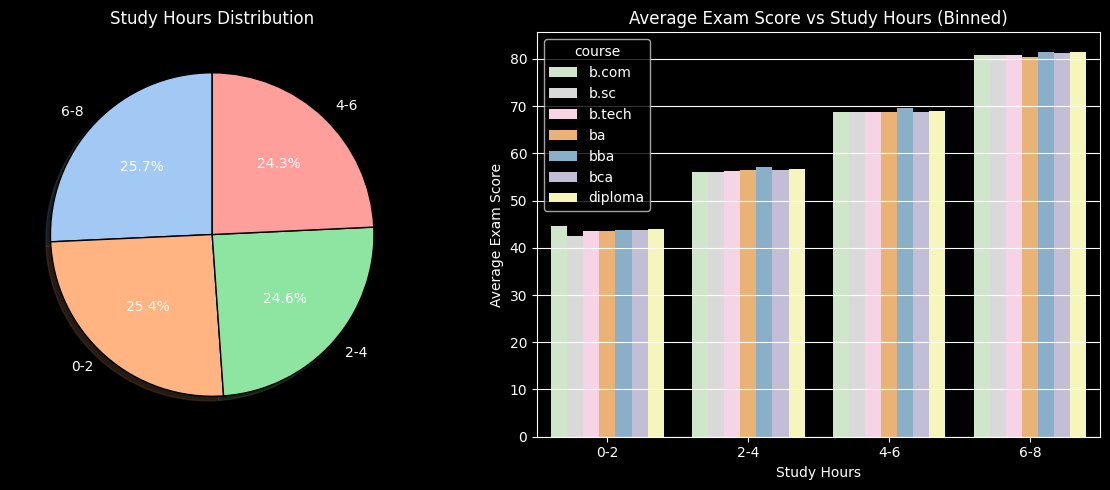

In [21]:
colors = sns.color_palette('pastel', train_data['study_hours_bin'].nunique())
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.pie(
    x=train_data['study_hours_bin'].value_counts().values,
    labels=train_data['study_hours_bin'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=colors,
    wedgeprops={'edgecolor':'black'}  
)
plt.title("Study Hours Distribution", fontsize=12)
plt.subplot(1,2,2)
sns.barplot(
    x='study_hours_bin',
    y='mean',
    hue='course',
    data=df,
    palette='Set3_r'
)
plt.title("Average Exam Score vs Study Hours (Binned)", fontsize=12)
plt.xlabel("Study Hours")
plt.ylabel("Average Exam Score")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [22]:
bins = [0, 50, 75, 100]  
labels = ['Low', 'Medium', 'High']
train_data['attendance_bin'] = pd.cut(train_data['class_attendance'], bins=bins, labels=labels, include_lowest=True)
test_data['attendance_bin'] = pd.cut(test_data['class_attendance'], bins=bins, labels=labels, include_lowest=True)

train_data['attendance_bin'].value_counts()

attendance_bin
High      288617
Medium    251659
Low        89724
Name: count, dtype: int64

In [23]:
df = train_data.groupby(["course",'attendance_bin'])['exam_score'].mean().reset_index()
df

/tmp/ipykernel_23/56929160.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = train_data.groupby(["course",'attendance_bin'])['exam_score'].mean().reset_index()


,course,attendance_bin,exam_score
0,b.com,Low,52.279257
1,b.com,Medium,59.728750
2,b.com,High,68.308537
3,b.sc,Low,50.660825
4,b.sc,Medium,59.527800
5,b.sc,High,68.494678
6,b.tech,Low,51.303489
7,b.tech,Medium,59.389573
8,b.tech,High,68.403937
9,ba,Low,51.371640


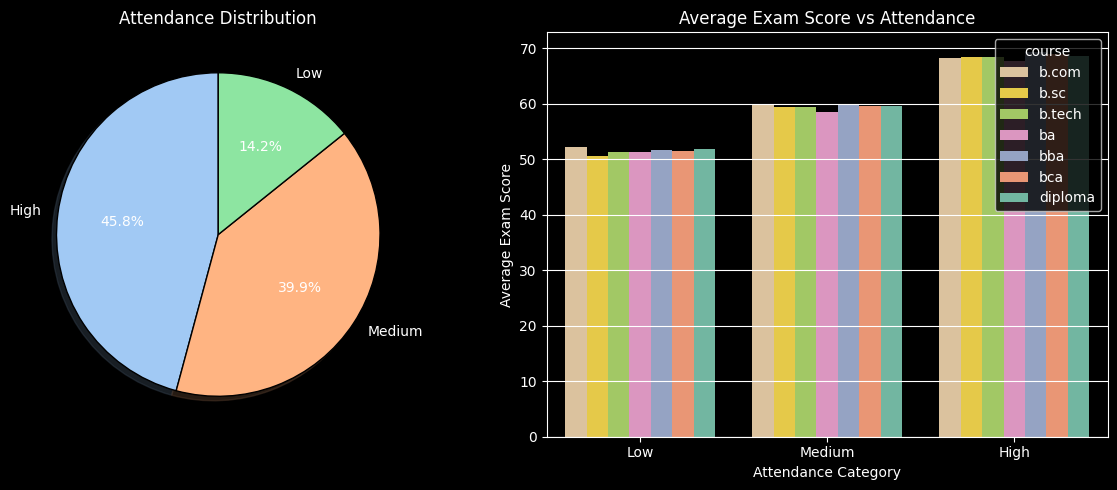

In [24]:
plt.figure(figsize=(12,5))
colors = sns.color_palette('pastel', 3)
plt.subplot(1,2,1)
plt.pie(
    x=train_data.attendance_bin.value_counts().values,
    labels=train_data.attendance_bin.value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)
plt.title("Attendance Distribution", fontsize=12)
plt.subplot(1,2,2)
sns.barplot(
    x='attendance_bin',
    y='exam_score',
    hue="course",
    data=df,
    palette='Set2_r'
)
plt.title("Average Exam Score vs Attendance", fontsize=12)
plt.xlabel("Attendance Category")
plt.ylabel("Average Exam Score")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [25]:
train_data.internet_access.value_counts()

internet_access
yes    579423
no      50577
Name: count, dtype: int64

In [26]:
df = train_data.groupby(["course","internet_access"]).agg(count_internet=('internet_access','count')).reset_index()
df

,course,internet_access,count_internet
0,b.com,no,8848
1,b.com,yes,102084
2,b.sc,no,8871
3,b.sc,yes,102683
4,b.tech,no,10293
5,b.tech,yes,120943
6,ba,no,5166
7,ba,yes,56823
8,bba,no,6172
9,bba,yes,69472


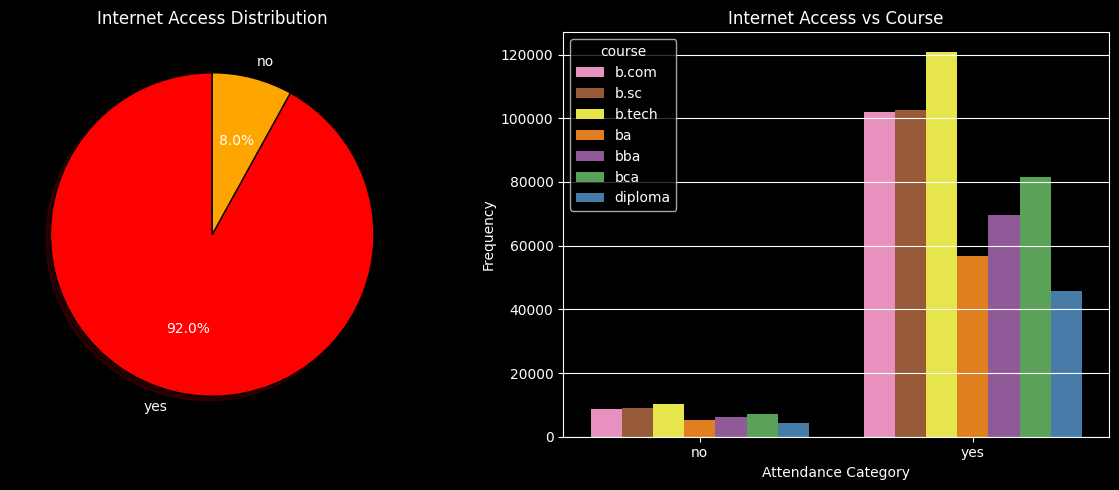

In [27]:
plt.figure(figsize=(12,5))
colors = ["red","orange"]
plt.subplot(1,2,1)
plt.pie(
    x=train_data.internet_access.value_counts().values,
    labels=train_data.internet_access.value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)
plt.title("Internet Access Distribution", fontsize=12)
plt.subplot(1,2,2)
sns.barplot(
    x='internet_access',
    y='count_internet',
    hue="course",
    data=df,
    palette='Set1_r'
)
plt.title("Internet Access vs Course", fontsize=12)
plt.xlabel("Attendance Category")
plt.ylabel("Frequency")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [28]:
min_sleep = train_data['sleep_hours'].min()
max_sleep = train_data['sleep_hours'].max()
print(f"Minimum Daily Sleep Hours: {min_sleep:.2f} , Maximum Daily Sleep Hours: {max_sleep:.2f}")

Minimum Daily Sleep Hours: 4.10 , Maximum Daily Sleep Hours: 9.90


In [29]:
bins = [4, 5, 6, 7, 8, 10] 
labels = ['4-5','5-6','6-7','7-8','8-10']
train_data['sleep_hours_bin'] = pd.cut(train_data['sleep_hours'], bins=bins, labels=labels, include_lowest=True)
test_data['sleep_hours_bin'] = pd.cut(test_data['sleep_hours'], bins=bins, labels=labels, include_lowest=True)

train_data['sleep_hours_bin'].value_counts()

sleep_hours_bin
8-10    216280
5-6     105442
7-8     104477
4-5     103381
6-7     100420
Name: count, dtype: int64

In [30]:
df = train_data.groupby(["course",'sleep_hours_bin'])['exam_score'].mean().reset_index()
df

/tmp/ipykernel_23/146527965.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = train_data.groupby(["course",'sleep_hours_bin'])['exam_score'].mean().reset_index()


,course,sleep_hours_bin,exam_score
0,b.com,4-5,58.359112
1,b.com,5-6,59.558522
2,b.com,6-7,61.861408
3,b.com,7-8,63.222951
4,b.com,8-10,65.898655
5,b.sc,4-5,57.714041
6,b.sc,5-6,59.192143
7,b.sc,6-7,61.627142
8,b.sc,7-8,63.011995
9,b.sc,8-10,65.916476


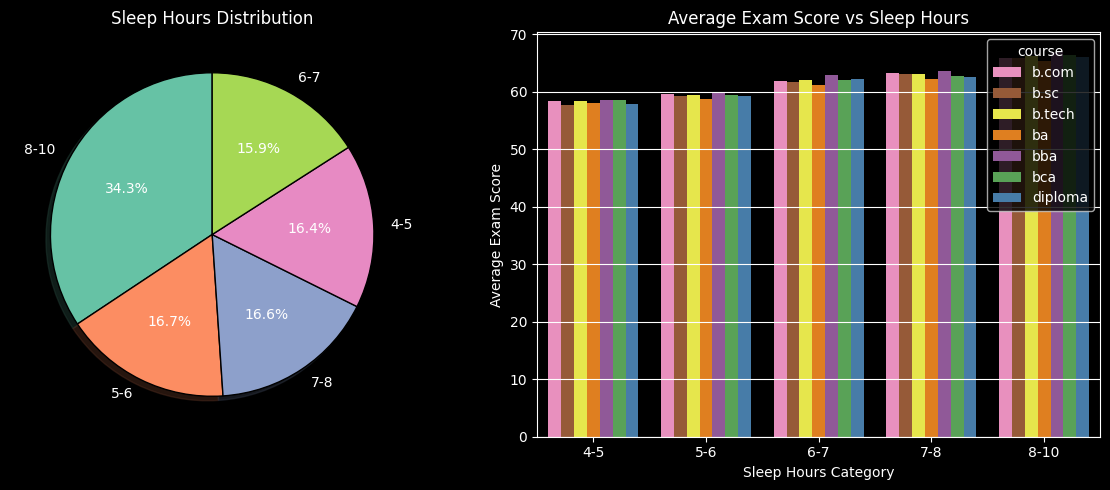

In [31]:
plt.figure(figsize=(12,5))
colors = sns.color_palette('Set2', len(train_data.sleep_hours_bin.unique()))
plt.subplot(1,2,1)
plt.pie(
    x=train_data.sleep_hours_bin.value_counts().values,
    labels=train_data.sleep_hours_bin.value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)
plt.title("Sleep Hours Distribution", fontsize=12)
plt.subplot(1,2,2)
sns.barplot(
    x='sleep_hours_bin',
    y='exam_score',
    hue="course",
    data=df,
    palette='Set1_r'
)
plt.title("Average Exam Score vs Sleep Hours", fontsize=12)
plt.xlabel("Sleep Hours Category")
plt.ylabel("Average Exam Score")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [32]:
train_data.sleep_quality.value_counts()

sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64

In [33]:
df = train_data.groupby(["course",'sleep_quality'])['exam_score'].mean().reset_index()
df

,course,sleep_quality,exam_score
0,b.com,average,62.598159
1,b.com,good,67.490866
2,b.com,poor,57.249205
3,b.sc,average,62.450786
4,b.sc,good,67.675494
5,b.sc,poor,56.704613
6,b.tech,average,62.620315
7,b.tech,good,68.006674
8,b.tech,poor,57.215231
9,ba,average,62.086230


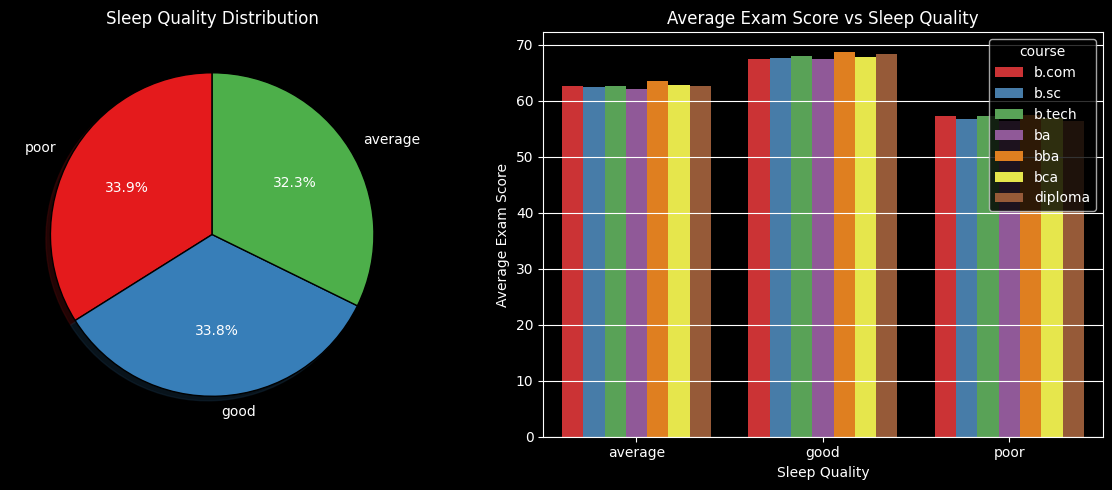

In [34]:
plt.figure(figsize=(12,5))
colors = sns.color_palette('Set1', len(train_data.sleep_quality.unique()))
plt.subplot(1,2,1)
plt.pie(
    x=train_data.sleep_quality.value_counts().values,
    labels=train_data.sleep_quality.value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)
plt.title("Sleep Quality Distribution", fontsize=12)
plt.subplot(1,2,2)
sns.barplot(
    x='sleep_quality',
    y='exam_score',
    hue="course",
    data=df,
    palette='Set1'
)
plt.title("Average Exam Score vs Sleep Quality", fontsize=12)
plt.xlabel("Sleep Quality")
plt.ylabel("Average Exam Score")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [35]:
train_data.study_method.value_counts()

study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64

In [36]:
df = train_data.groupby(["course",'study_method'])['exam_score'].mean().reset_index()
df

,course,study_method,exam_score
0,b.com,coaching,68.865920
1,b.com,group study,60.446533
2,b.com,mixed,64.854600
3,b.com,online videos,59.843162
4,b.com,self-study,57.866867
5,b.sc,coaching,69.434393
6,b.sc,group study,60.665503
7,b.sc,mixed,65.274705
8,b.sc,online videos,59.626078
9,b.sc,self-study,56.900108


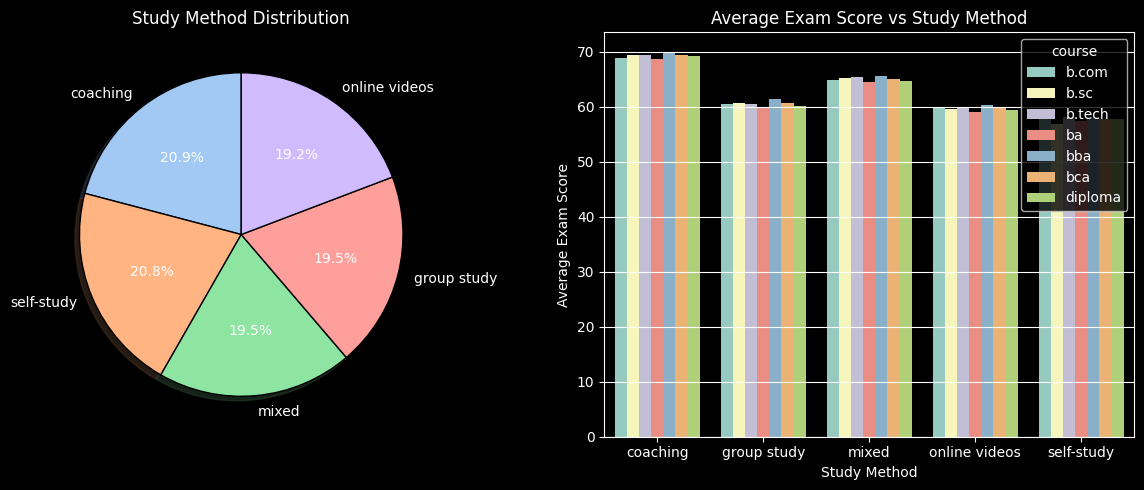

In [37]:
plt.figure(figsize=(12,5))
colors = sns.color_palette('pastel', len(train_data.study_method.unique()))
plt.subplot(1,2,1)
plt.pie(
    x=train_data.study_method.value_counts().values,
    labels=train_data.study_method.value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)
plt.title("Study Method Distribution", fontsize=12)
plt.subplot(1,2,2)
sns.barplot(
    x='study_method',
    y='exam_score',
    hue="course",
    data=df,
    palette='Set3'
)
plt.title("Average Exam Score vs Study Method", fontsize=12)
plt.xlabel("Study Method")
plt.ylabel("Average Exam Score")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [38]:
train_data.facility_rating.value_counts()

facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64

In [39]:
df = train_data.groupby(["course",'facility_rating'])['exam_score'].mean().reset_index()
df

,course,facility_rating,exam_score
0,b.com,high,66.571138
1,b.com,low,58.406609
2,b.com,medium,62.935656
3,b.sc,high,66.621012
4,b.sc,low,57.528673
5,b.sc,medium,63.020480
6,b.tech,high,66.724075
7,b.tech,low,57.936694
8,b.tech,medium,62.973410
9,ba,high,65.948257


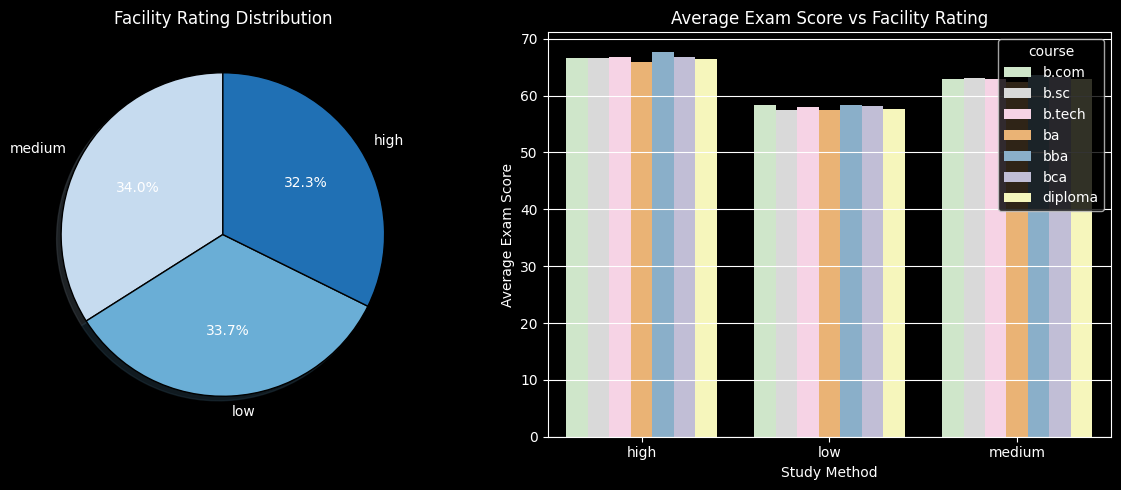

In [40]:
plt.figure(figsize=(12,5))
colors = sns.color_palette('Blues', len(train_data.facility_rating.unique()))
plt.subplot(1,2,1)
plt.pie(
    x=train_data.facility_rating.value_counts().values,
    labels=train_data.facility_rating.value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)
plt.title("Facility Rating Distribution", fontsize=12)
plt.subplot(1,2,2)
sns.barplot(
    x='facility_rating',
    y='exam_score',
    hue="course",
    data=df,
    palette='Set3_r'
)
plt.title("Average Exam Score vs Facility Rating", fontsize=12)
plt.xlabel("Study Method")
plt.ylabel("Average Exam Score")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [41]:
train_data.exam_difficulty.value_counts()

exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64

In [42]:
df = train_data.groupby(["course",'exam_difficulty'])['exam_score'].mean().reset_index()
df

,course,exam_difficulty,exam_score
0,b.com,easy,62.239675
1,b.com,hard,62.976480
2,b.com,moderate,62.561984
3,b.sc,easy,62.024118
4,b.sc,hard,62.087733
5,b.sc,moderate,62.488623
6,b.tech,easy,62.308195
7,b.tech,hard,62.637780
8,b.tech,moderate,62.584742
9,ba,easy,61.657900


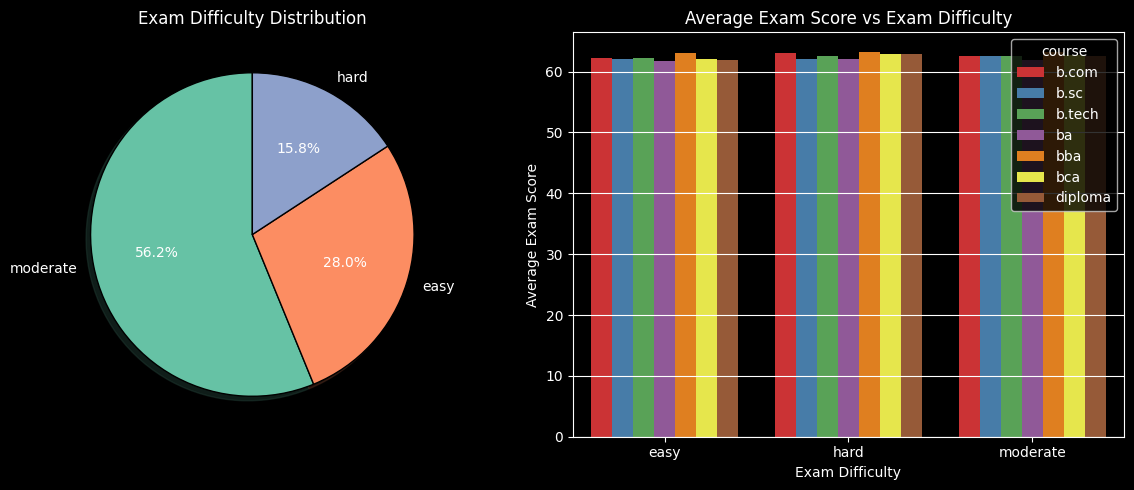

In [43]:
plt.figure(figsize=(12,5))
colors = sns.color_palette('Set2', len(train_data.facility_rating.unique()))
plt.subplot(1,2,1)
plt.pie(
    x=train_data.exam_difficulty.value_counts().values,
    labels=train_data.exam_difficulty.value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)
plt.title("Exam Difficulty Distribution", fontsize=12)
plt.subplot(1,2,2)
sns.barplot(
    x='exam_difficulty',
    y='exam_score',
    hue="course",
    data=df,
    palette='Set1'
)
plt.title("Average Exam Score vs Exam Difficulty", fontsize=12)
plt.xlabel("Exam Difficulty")
plt.ylabel("Average Exam Score")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [44]:
min_exam_score = train_data.exam_score.min()
max_exam_score = train_data.exam_score.max()
print(f"Min Exam Score: {min_exam_score} , Largest Exam Score: {max_exam_score}")

Min Exam Score: 19.599 , Largest Exam Score: 100.0


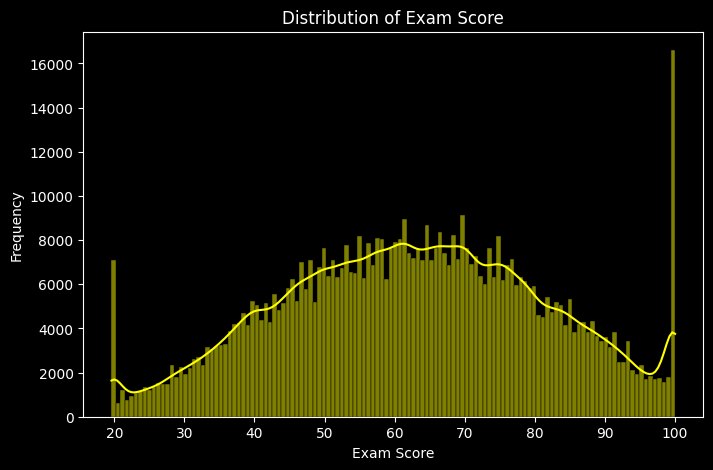

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(train_data['exam_score'], kde=True, color='yellow', edgecolor='black')  
plt.title("Distribution of Exam Score", fontsize=12)  
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

In [46]:
numerical_cols = train_data.select_dtypes(include="number").columns
numerical_cols

Index(['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_score'],
      dtype='object')

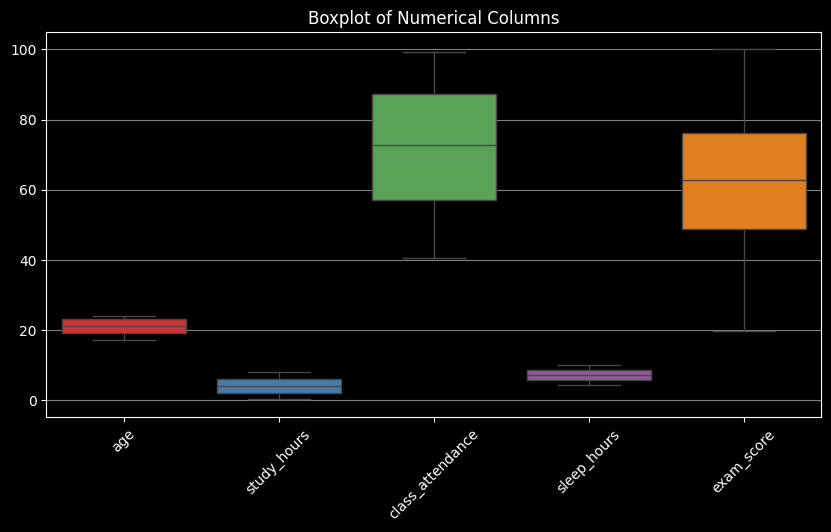

In [47]:
plt.figure(figsize=(10,5))
sns.boxplot(data=train_data[numerical_cols[1:]], palette="Set1")
plt.title("Boxplot of Numerical Columns", fontsize=12)
plt.xticks(rotation=45)  
plt.grid(axis='y', alpha=0.5)
plt.show()

**Preprocessing**

In [48]:
cate_columns = train_data.select_dtypes(include=["O","category"]).columns
cate_columns

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'study_hours_bin',
       'attendance_bin', 'sleep_hours_bin'],
      dtype='object')

In [49]:
encoder = LabelEncoder()
for col in cate_columns:
    train_data[col] = encoder.fit_transform(train_data[col])
    test_data[col] = encoder.fit_transform(test_data[col])
train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,study_hours_bin,attendance_bin,sleep_hours_bin
0,0,21,0,1,7.91,98.8,0,4.9,0,3,1,0,78.3,3,0,0
1,1,18,2,6,4.95,94.8,1,4.7,2,4,2,2,46.7,2,0,0
2,2,20,0,1,4.68,92.6,1,5.8,2,0,0,2,99.0,2,0,1
3,3,19,1,1,2.00,49.5,1,8.3,0,1,0,2,63.9,0,1,4
4,4,23,1,5,7.65,86.9,1,9.6,1,4,0,0,100.0,3,0,4


In [50]:
corr = train_data.corr()
corr

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,study_hours_bin,attendance_bin,sleep_hours_bin
id,1.000000,-0.000581,-0.000288,0.000735,0.000346,0.000677,0.001328,0.001416,-0.001730,0.001457,-0.000522,0.000637,0.000372,-0.000152,-0.000811,0.001515
age,-0.000581,1.000000,-0.004584,-0.002196,0.007545,0.005628,-0.001453,0.005864,-0.004372,-0.009125,-0.005498,0.009227,0.010472,0.006769,-0.011473,0.005570
gender,-0.000288,-0.004584,1.000000,0.007267,0.008299,-0.003249,-0.000553,-0.006919,0.000282,-0.007747,-0.000033,-0.003878,0.004748,0.006754,0.004763,-0.006643
course,0.000735,-0.002196,0.007267,1.000000,-0.002468,-0.001681,-0.003214,0.003846,0.008603,-0.011059,0.002926,0.006054,0.003874,-0.005540,0.004039,0.001074
study_hours,0.000346,0.007545,0.008299,-0.002468,1.000000,0.087617,-0.005347,0.042491,-0.025332,-0.035819,-0.002559,0.010778,0.762267,0.968901,-0.041949,0.036411
class_attendance,0.000677,0.005628,-0.003249,-0.001681,0.087617,1.000000,0.016103,0.029263,-0.000718,-0.017303,-0.012854,0.000330,0.360954,0.086380,-0.689999,0.028877
internet_access,0.001328,-0.001453,-0.000553,-0.003214,-0.005347,0.016103,1.000000,-0.008601,-0.005200,0.005936,0.003389,-0.004005,0.000447,-0.003090,-0.013868,-0.009116
sleep_hours,0.001416,0.005864,-0.006919,0.003846,0.042491,0.029263,-0.008601,1.000000,-0.016287,-0.005384,0.003048,0.001333,0.167410,0.040335,-0.017261,0.969536
sleep_quality,-0.001730,-0.004372,0.000282,0.008603,-0.025332,-0.000718,-0.005200,-0.016287,1.000000,0.018553,-0.001313,-0.006434,-0.124749,-0.025299,-0.003536,-0.016095
study_method,0.001457,-0.009125,-0.007747,-0.011059,-0.035819,-0.017303,0.005936,-0.005384,0.018553,1.000000,-0.001505,0.004892,-0.183431,-0.038091,0.005530,-0.008335


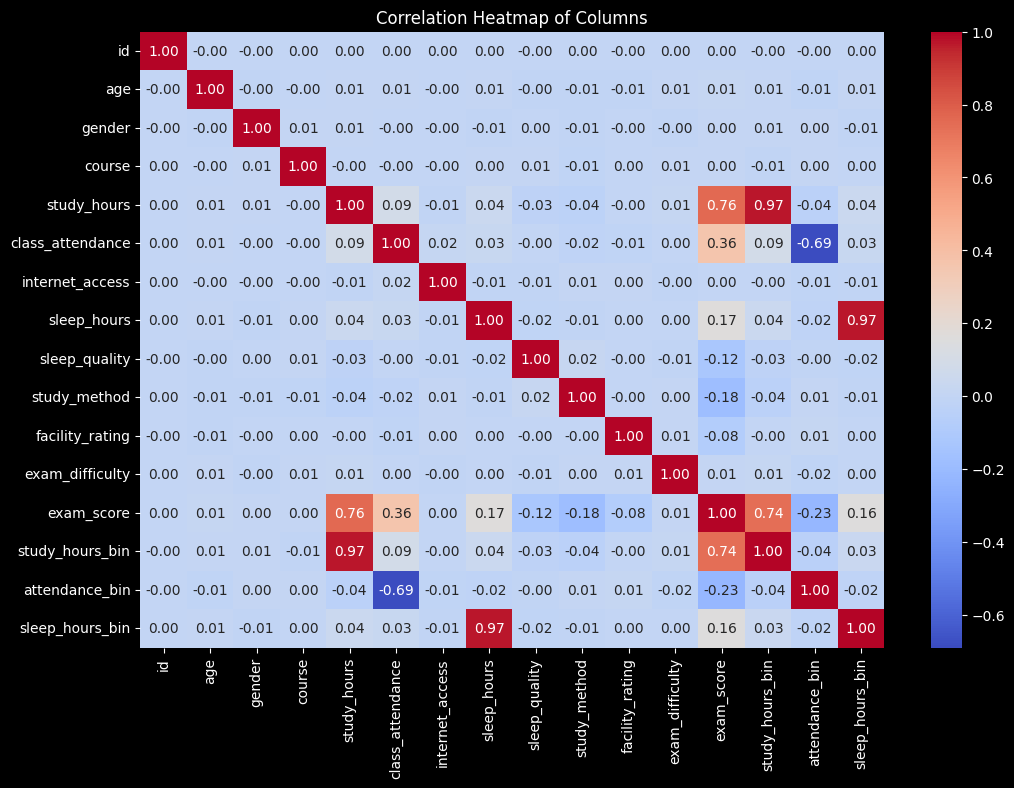

In [51]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,  
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f"
)
plt.title("Correlation Heatmap of Columns", fontsize=12)
plt.show()

In [52]:
exam_score_corr = corr.exam_score
exam_score_corr

id                  0.000372
age                 0.010472
gender              0.004748
course              0.003874
study_hours         0.762267
class_attendance    0.360954
internet_access     0.000447
sleep_hours         0.167410
sleep_quality      -0.124749
study_method       -0.183431
facility_rating    -0.076605
exam_difficulty     0.008337
exam_score          1.000000
study_hours_bin     0.741855
attendance_bin     -0.227446
sleep_hours_bin     0.158590
Name: exam_score, dtype: float64

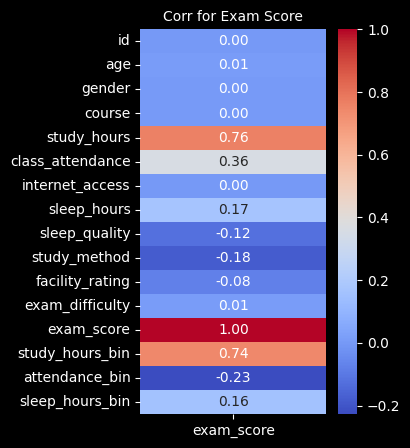

In [53]:
plt.figure(figsize=(3,5))
sns.heatmap(
    exam_score_corr.to_frame(),  
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f"
)
plt.title("Corr for Exam Score", fontsize=10)
plt.show()

In [54]:
X = train_data.iloc[:,1:-4]
columns = X.columns
y = train_data.exam_score
X.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,21,0,1,7.91,98.8,0,4.9,0,3,1,0
1,18,2,6,4.95,94.8,1,4.7,2,4,2,2
2,20,0,1,4.68,92.6,1,5.8,2,0,0,2
3,19,1,1,2.00,49.5,1,8.3,0,1,0,2
4,23,1,5,7.65,86.9,1,9.6,1,4,0,0


In [55]:
y.head()

0     78.3
1     46.7
2     99.0
3     63.9
4    100.0
Name: exam_score, dtype: float64

In [56]:
test = test_data.iloc[:,1:-3]
test.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,24,2,3,6.85,65.2,1,5.2,2,1,0,0
1,18,1,6,6.61,45.0,0,9.3,2,0,1,0
2,24,0,2,6.60,98.5,1,6.2,1,1,2,2
3,24,1,6,3.03,66.3,1,5.7,0,2,2,2
4,20,0,2,2.03,42.4,1,9.2,0,0,1,2


In [57]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
test = scaler.transform(test)
X = pd.DataFrame(X,columns=columns)
test = pd.DataFrame(test,columns=columns)
X.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,0.571429,0.0,0.166667,1.000000,0.989796,0.0,0.137931,0.0,0.75,0.5,0.0
1,0.142857,1.0,1.000000,0.621967,0.921769,1.0,0.103448,1.0,1.00,1.0,1.0
2,0.428571,0.0,0.166667,0.587484,0.884354,1.0,0.293103,1.0,0.00,0.0,1.0
3,0.285714,0.5,0.166667,0.245211,0.151361,1.0,0.724138,0.0,0.25,0.0,1.0
4,0.857143,0.5,0.833333,0.966794,0.787415,1.0,0.948276,0.5,1.00,0.0,0.0


In [58]:
poly = PolynomialFeatures(1)
X = poly.fit_transform(X)
test = poly.transform(test)
X[5]

array([1.        , 1.        , 0.5       , 0.        , 0.63346105,
       0.75680272, 1.        , 0.9137931 , 0.        , 0.75      ,
       1.        , 1.        ])

In [59]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42,shuffle=True)
print(f"Input Train Size: {X_train.shape} , Input Test Size: {X_test.shape}")
print(f"Output Train Size: {y_train.shape} , Output Test Size: {y_test.shape}")

Input Train Size: (504000, 12) , Input Test Size: (126000, 12)
Output Train Size: (504000,) , Output Test Size: (126000,)


**Models**

In [60]:
models_params = {

    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },

    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 5]
        }
    },

    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(
            objective="reg:squarederror",
            random_state=42
        ),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1]
        }
    },

    "CatBoost": {
        "model": CatBoostRegressor(
            verbose=0,
            random_state=42
        ),
        "params": {
            "iterations": [300, 500],
            "depth": [6, 8],
            "learning_rate": [0.05, 0.1]
        }
    },

    "LightGBM": {
        "model": LGBMRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 300],
            "learning_rate": [0.05, 0.1],
            "num_leaves": [31, 50]
        }
    }
}

results = []

for name, mp in models_params.items():
    print(f"Training {name} ...")

    grid = GridSearchCV(
        mp["model"],
        mp["params"],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best Estimator": best_model,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df


Training Linear Regression ...
Training Decision Tree ...
Training Random Forest ...
Training XGBoost ...
Training CatBoost ...
Training LightGBM ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.129258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 594
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 11
[LightGBM] [Info] Start training from score 62.512328


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025969 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 595
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 11
[LightGBM] [Info] Start training from score 62.466310


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.105905 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 594
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 11
[LightGBM] [Info] Start training from score 62.486843
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 595
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 11
[LightGBM] [Info] Start training from score 62.480870
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 593
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 11
[LightGBM] [Info] Start training from score 62.482335


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,Best Params,Best Estimator,R2,MAE,RMSE
4,CatBoost,"{'depth': 8, 'iterations': 500, 'learning_rate...",<catboost.core.CatBoostRegressor object at 0x7...,0.784224,6.986743,8.760150
5,LightGBM,"{'learning_rate': 0.1, 'n_estimators': 300, 'n...","LGBMRegressor(n_estimators=300, num_leaves=50,...",0.783865,6.991534,8.767432
3,XGBoost,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...","XGBRegressor(base_score=None, booster=None, ca...",0.783564,6.992053,8.773536
2,Random Forest,"{'max_depth': 20, 'n_estimators': 200}","(DecisionTreeRegressor(max_depth=20, max_featu...",0.769340,7.209548,9.057231
1,Decision Tree,"{'max_depth': 10, 'min_samples_leaf': 5, 'min_...","DecisionTreeRegressor(max_depth=10, min_sample...",0.754004,7.475464,9.353495
0,Linear Regression,{},LinearRegression(),0.721894,7.982542,9.945237


In [61]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: CatBoost


In [62]:
best_model = results_df.iloc[0]["Best Estimator"]
submission_pred = best_model.predict(test)
submission = pd.DataFrame({
    "id": test_data["id"],
    "exam_score": submission_pred
})
submission.head()
submission.to_csv("submission.csv", index=False)

**PowerBI Dashboard**

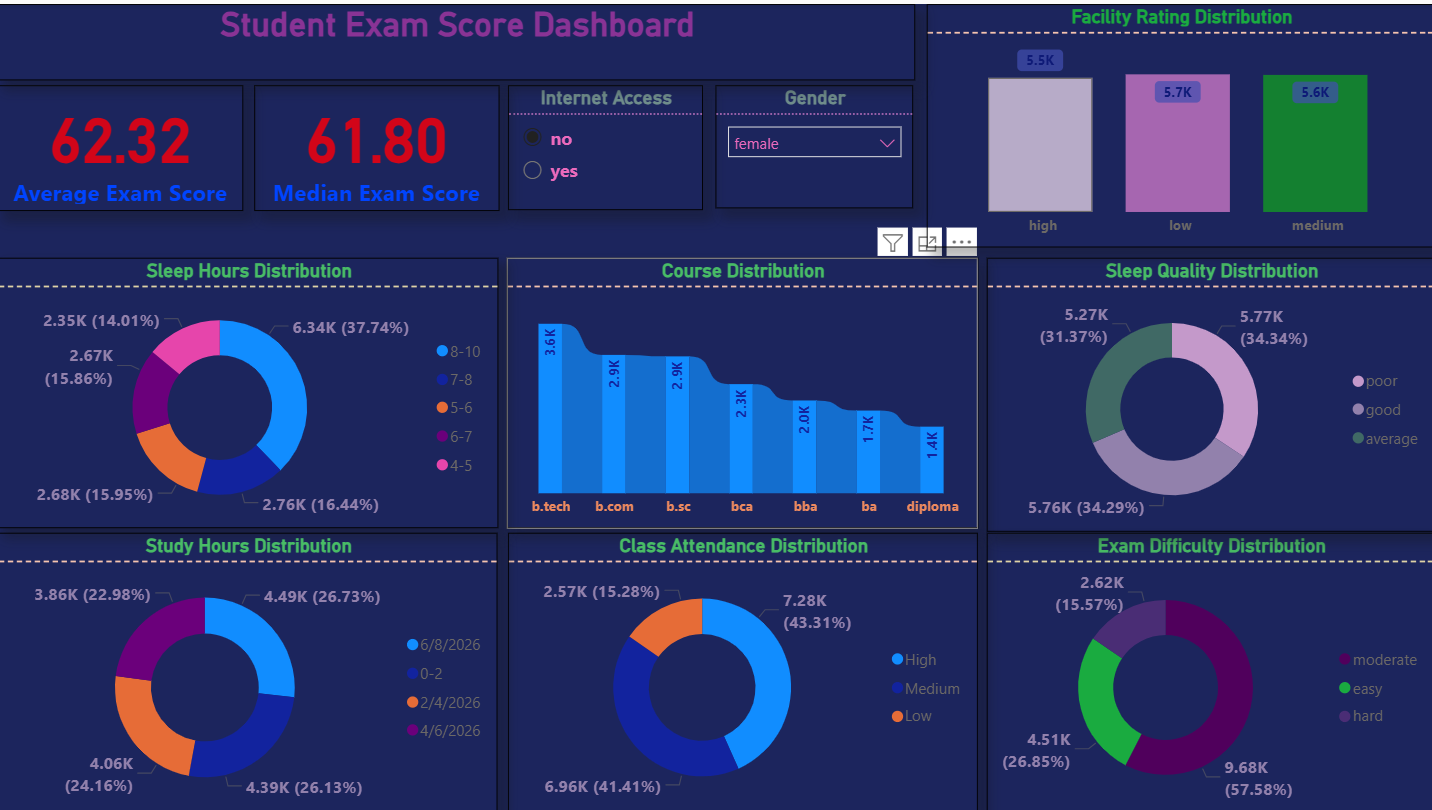